# Pytorch Transformation Pipeline
Will take in the ouput from Cleaning_Data.ipnyb and change into pytorch input as well as run some sanity checks. Notebooks are segmented in case we change the structure.
Tutorial: https://machinelearningmastery.com/pytorch-tutorial-develop-deep-learning-models/

```
conda create -p /projects/dagr5998/envs/ml python=3.10
conda activate /projects/dagr5998/envs/ml
conda install -c conda-forge pytorch-cpu xarray netcdf4 matplotlib ipykernel 
python -m ipykernel install --user --name ml --display-name "Python for Machine Learning"
```

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import netCDF4
from pathlib import Path
from datetime import datetime
import json
import torch

## Config

In [2]:
IN_DIR = Path("/projects/dagr5998/icepack_array_output/test2_output") 
OUT_DIR = Path("/projects/dagr5998/icepack_split_output/test2_split")
window = 365 # in days, length of input series
training_vars = ["Tair", "fcondtop", 
                 'aicen_ncat1', 'aicen_ncat2', 'aicen_ncat3', 'aicen_ncat4', 'aicen_ncat5', 
                 'vicen_ncat1', 'vicen_ncat2', 'vicen_ncat3', 'vicen_ncat4', 'vicen_ncat5', 
                 'vsnon_ncat1', 'vsnon_ncat2', 'vsnon_ncat3', 'vsnon_ncat4','vsnon_ncat5']
SEED = 42
split_var = "member" #member, group, or window
TEST_VALUES = [1]

#### Loading and Checking Data

In [3]:
def make_index(run_ids, T, input_window):
    # build the indicies for the input series, have step incase we want over
    index = []
    for r in run_ids:
        t0 = 0
        while t0 + input_window <= T:
            index.append([int(r), t0])
            t0 += input_window
    return index


In [4]:
X = np.load(IN_DIR / "X.npy") # input tensor
Y = np.load(IN_DIR / "Y.npy") # output tensor
members = np.load(IN_DIR / "member.npy") # change parameter set index
groups = np.load(IN_DIR / "group.npy") # ensemble member set index
windows = np.load(IN_DIR/"window.npy")
sample_len = X.shape[1]

In [5]:
with open(IN_DIR / 'config.json') as f:
    config = json.load(f)
channels = config["channels"]

In [12]:
assert list(config['shape'])==list(X.shape) 
assert(X.shape[0] == Y.shape[0] == members.shape[0] ==groups.shape[0]) #confirms the datasets match
assert set(training_vars).issubset(channels)
input_window  = window * (24 // config["aggregated hours"])

In [7]:
Xt = torch.tensor(X) # change for pytorch
Yt = torch.tensor(Y)
var_ind_list = [channels.index(i) for i in training_vars] # get indicies of variables the model is training on
Xt = Xt[:,:,var_ind_list] # selects relevant variables

#### Splitting Testing and Training Data

In [8]:
split_col = {"member": members, "group": groups, "window": windows}[split_var]
test_mask = np.isin(split_col, TEST_VALUES) #lets the split be set at top

In [9]:
train_ind = np.flatnonzero(~test_mask)
test_ind = np.flatnonzero(test_mask)

In [13]:
train_index = make_index(train_ind, sample_len, input_window)
test_index  = make_index(test_ind,  sample_len, input_window)#[run,start timestep]

In [14]:
train_runs = np.unique([r for r, b in train_index])
test_runs = np.unique([r for r, b in test_index])

In [ ]:
#test_index 

### Making Dataset Class

In [15]:
mu = Xt[train_runs].mean(dim=[0,1])#calculate the mean/sd of the remaining channel
sd = Xt[train_runs].std(dim=[0,1])
print(sd.min(), sd.max())
print(training_vars[sd.argmin()], training_vars[sd.argmax()]) # highest and lowest variance channels
#plt.plot(Xt[0,:,sd.argmax()])

tensor(0.0016) tensor(11.8017)
vsnon_ncat1 Tair


In [16]:
class IcepackDataset(torch.utils.data.Dataset):
    def __init__(self, X, Y, index, window, mu, sd):
        self.X = X# (N, T, C)
        self.Y = Y# (N, P)
        self.index = index #array of [run, start]
        self.window = window
        self.mu, self.sd = mu,sd  

    def __getitem__(self, ind):
        run,start = self.index[ind]
        xnorm = self.X[run, start:start + self.window]# (Window, C)
        return (xnorm - self.mu)/self.sd, self.Y[run]

    def __len__(self):
        return len(self.index)

In [17]:
train_ds = IcepackDataset(Xt, Yt, train_index, input_window,mu,sd)
test_ds  = IcepackDataset(Xt, Yt, test_index,  input_window,mu,sd)

In [18]:
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=8, shuffle=True) #shuffle the training data 
test_loader  = torch.utils.data.DataLoader(test_ds,  batch_size=8, shuffle=False)

In [19]:
x,y = next(iter(test_loader))

In [20]:
print(x.mean(dim=(0,1))[:5])
print(x.std(dim=(0,1))[:5])

tensor([-0.0840, -0.4241, -0.3002, -0.8215, -1.1068])
tensor([1.0420, 1.4091, 0.1689, 0.1032, 0.6676])


In [21]:
x.shape

torch.Size([8, 365, 17])

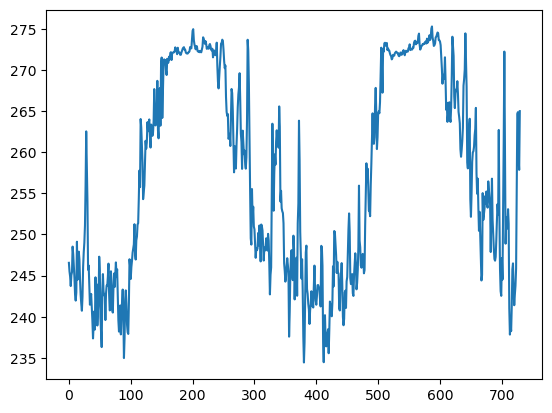

In [22]:
plt.plot(Xt[0,:,0])

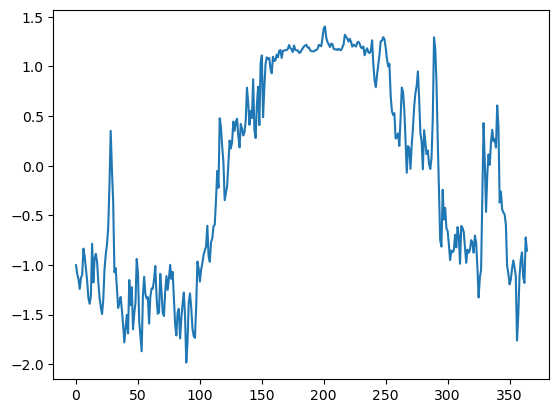

In [23]:
plt.plot(x[0,:,0])

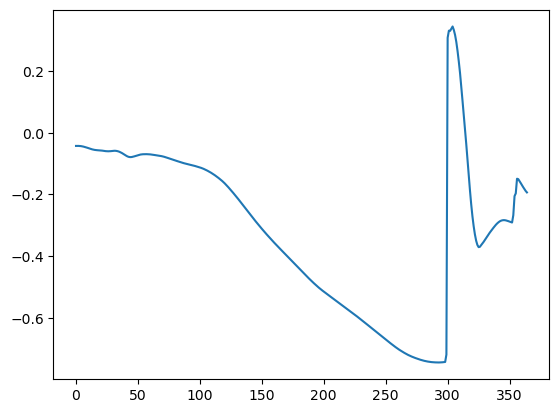

In [24]:
plt.plot(x[0,:,2]+x[0,:,3]+x[0,:,4]+x[0,:,5]+x[0,:,6])

#### Saved Output

In [30]:
Xt.shape

torch.Size([140, 730, 17])

In [29]:
np.save(OUT_DIR / "train_index.npy", np.array(train_index, dtype=np.int32))  # (n_train, 2) [run, start]
np.save(OUT_DIR / "test_index.npy",  np.array(test_index,  dtype=np.int32))
np.save(OUT_DIR / "train_ind.npy",   train_ind)                              # run indices per side
np.save(OUT_DIR / "test_ind.npy",    test_ind)
np.save(OUT_DIR / "mu.npy",          mu.numpy())                             # (C_used,)
np.save(OUT_DIR / "sd.npy",          sd.numpy())


split_config = {
    "in_path":       str(IN_PATH),
    "training_vars": training_vars,
    "var_ind_list":  var_ind_list,
    "window_days":   window,
    "input_window":  input_window,
    "split_var":     split_var,
    "test_values":   TEST_VALUES,
    "seed":          SEED,
    "n_train":       len(train_index),
    "n_test":        len(test_index),
    "created":       datetime.now().isoformat(timespec="seconds"),
}
(OUT_DIR / "split_config.json").write_text(json.dumps(split_config, indent=2))

753